# Sprawozdanie analityczne - Medical Student Mental Health

Celem notebooka jest analiza eksploracyjna danych Carrard et al. 2022 MedTeach, podobna układem do wcześniejszej części analitycznej.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Wczytanie danych

In [2]:
df = pd.read_csv("Data-Carrard-et-al.-2022-MedTeach.csv")
codebook = pd.read_csv("Codebook-Carrard-et-al.-2022-MedTeach.csv", sep=";", engine="python")
print("Kształt zbioru:", df.shape)
display(df.head())

Kształt zbioru: (886, 20)


,id,age,year,sex,glang,part,job,stud_h,health,psyt,jspe,qcae_cog,qcae_aff,amsp,erec_mean,cesd,stai_t,mbi_ex,mbi_cy,mbi_ea
0,2,18,1,1,120,1,0,56,3,0,88,62,27,17,0.738095,34,61,17,13,20
1,4,26,4,1,1,1,0,20,4,0,109,55,37,22,0.690476,7,33,14,11,26
2,9,21,3,2,1,0,0,36,3,0,106,64,39,17,0.690476,25,73,24,7,23
3,10,21,2,2,1,0,1,51,5,0,101,52,33,18,0.833333,17,48,16,10,21
4,13,21,3,1,1,1,0,22,4,0,102,58,28,21,0.690476,14,46,22,14,23


In [3]:
print("Kolumny:")
print(df.columns.tolist())
print("Braki danych:", int(df.isnull().sum().sum()))
display(codebook[["Variable Name", "Variable Label", "Variable Scale"]])

Kolumny:
['id', 'age', 'year', 'sex', 'glang', 'part', 'job', 'stud_h', 'health', 'psyt', 'jspe', 'qcae_cog', 'qcae_aff', 'amsp', 'erec_mean', 'cesd', 'stai_t', 'mbi_ex', 'mbi_cy', 'mbi_ea']
Braki danych: 0


,Variable Name,Variable Label,Variable Scale
0,id,Participants ID number,string
1,age,age at questionnaire 20-21,numeric
2,year,CURICULUM YEAR : In which curriculum year are ...,1=Bmed1; 2=Bmed2; 3=Bmed3; 4=Mmed1; 5=Mmed2; 6...
3,sex,GENDER : To which gender do you identify the m...,1=Man; 2=Woman; 3=Non-binary
4,glang,MOTHER TONGUE: What is your mother tongue?,1=French; 15=German; 20=English; 37=Arab; 51=B...
5,part,PARTNERSHIP STATUS : Do you have a partner?,0=No; 1=Yes
6,job,HAVING A JOB : Do you have a paid job?,0=No; 1=Yes
7,stud_h,"HOURS OF STUDY PER WEEK : On average, how many...",NaN
8,health,SATISFACTION WITH HEALTH : How satisfied are y...,1=Verydissatisfied; 2=Dissatisfied; 3=Neithers...
9,psyt,PSYCHOTHERAPY LAST YEAR : During the last 12 m...,0=No; 1=Yes


W 7 punkcie NaN oznacza pytanie do ankietowanych odnośnie ilości godzin w pracy

## 2. Przygotowanie danych
Dodano czytelne etykiety kategorii oraz zmienną określającą podwyższone ryzyko depresji na podstawie progu CES-D >= 16.

In [4]:
sex_map = {1:"Mężczyźni", 2:"Kobiety", 3:"Osoby niebinarne"}
year_map = {1:"Bmed1", 2:"Bmed2", 3:"Bmed3", 4:"Mmed1", 5:"Mmed2", 6:"Mmed3"}

df["sex_label"] = df["sex"].map(sex_map)
df["year_label"] = df["year"].map(year_map)
df["depression_risk"] = np.where(df["cesd"] >= 16, "Ryzyko depresji", "Brak podwyższonego ryzyka")
display(df.head())

,id,age,year,sex,glang,part,job,stud_h,health,psyt,...,amsp,erec_mean,cesd,stai_t,mbi_ex,mbi_cy,mbi_ea,sex_label,year_label,depression_risk
0,2,18,1,1,120,1,0,56,3,0,...,17,0.738095,34,61,17,13,20,Mężczyźni,Bmed1,Ryzyko depresji
1,4,26,4,1,1,1,0,20,4,0,...,22,0.690476,7,33,14,11,26,Mężczyźni,Mmed1,Brak podwyższonego ryzyka
2,9,21,3,2,1,0,0,36,3,0,...,17,0.690476,25,73,24,7,23,Kobiety,Bmed3,Ryzyko depresji
3,10,21,2,2,1,0,1,51,5,0,...,18,0.833333,17,48,16,10,21,Kobiety,Bmed2,Ryzyko depresji
4,13,21,3,1,1,1,0,22,4,0,...,21,0.690476,14,46,22,14,23,Mężczyźni,Bmed3,Brak podwyższonego ryzyka


## 3. Statystyki opisowe

In [5]:
summary_cols = ["age", "stud_h", "health", "jspe", "qcae_cog", "qcae_aff", "amsp", "erec_mean", "cesd", "stai_t", "mbi_ex", "mbi_cy", "mbi_ea"]
display(df[summary_cols].describe().T.round(2))
print("Liczba osób z CES-D >= 16:", int((df["cesd"] >= 16).sum()))
print("Udział procentowy:", round((df["cesd"] >= 16).mean() * 100, 2), "%")

,count,mean,std,min,25%,50%,75%,max
age,886.0,22.38,3.30,17.00,20.00,22.00,24.00,49.00
stud_h,886.0,25.29,15.93,0.00,12.00,25.00,36.00,70.00
health,886.0,3.78,1.06,1.00,3.00,4.00,5.00,5.00
jspe,886.0,106.37,8.78,67.00,101.00,107.00,113.00,125.00
qcae_cog,886.0,58.53,6.57,37.00,54.00,58.00,63.00,76.00
qcae_aff,886.0,34.78,5.38,18.00,31.00,35.00,39.00,48.00
amsp,886.0,23.15,4.99,6.00,20.00,23.00,26.75,35.00
erec_mean,886.0,0.72,0.09,0.36,0.67,0.73,0.79,0.95
cesd,886.0,18.05,11.48,0.00,9.00,16.00,25.00,56.00
stai_t,886.0,42.90,11.98,20.00,34.00,43.00,51.00,77.00


Liczba osób z CES-D >= 16: 461
Udział procentowy: 52.03 %


## 4. Analiza rozkładów i zależności

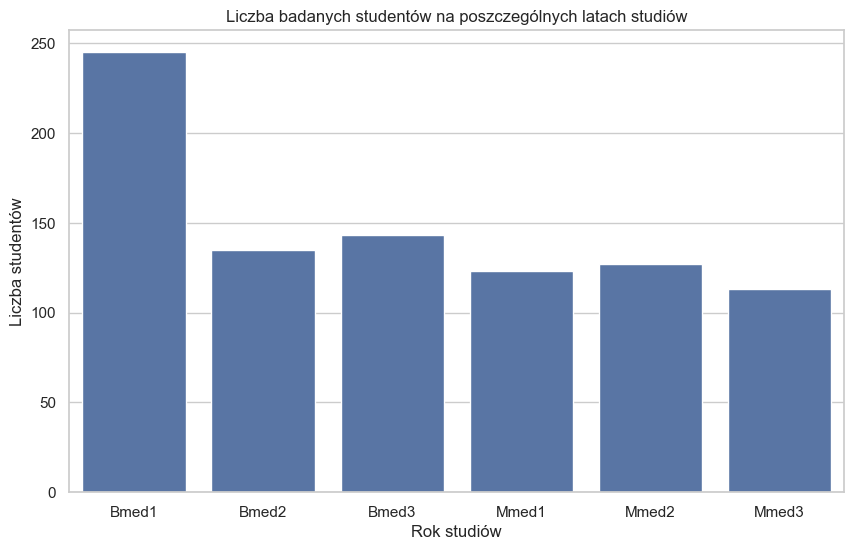

In [6]:
plt.figure()
sns.countplot(data=df, x="year_label", order=["Bmed1", "Bmed2", "Bmed3", "Mmed1", "Mmed2", "Mmed3"])
plt.title("Liczba badanych studentów na poszczególnych latach studiów")
plt.xlabel("Rok studiów")
plt.ylabel("Liczba studentów")
plt.show()

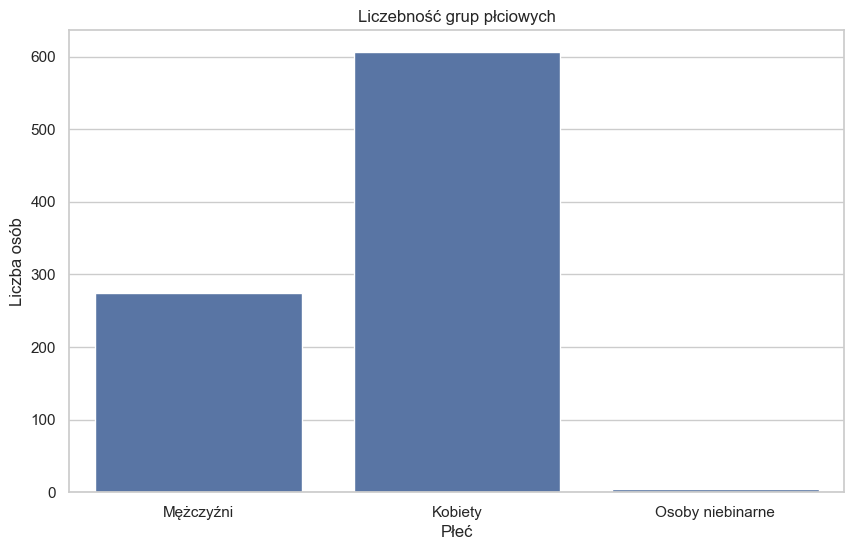

In [7]:
plt.figure()
sns.countplot(data=df, x="sex_label", order=["Mężczyźni", "Kobiety", "Osoby niebinarne"])
plt.title("Liczebność grup płciowych")
plt.xlabel("Płeć")
plt.ylabel("Liczba osób")
plt.show()

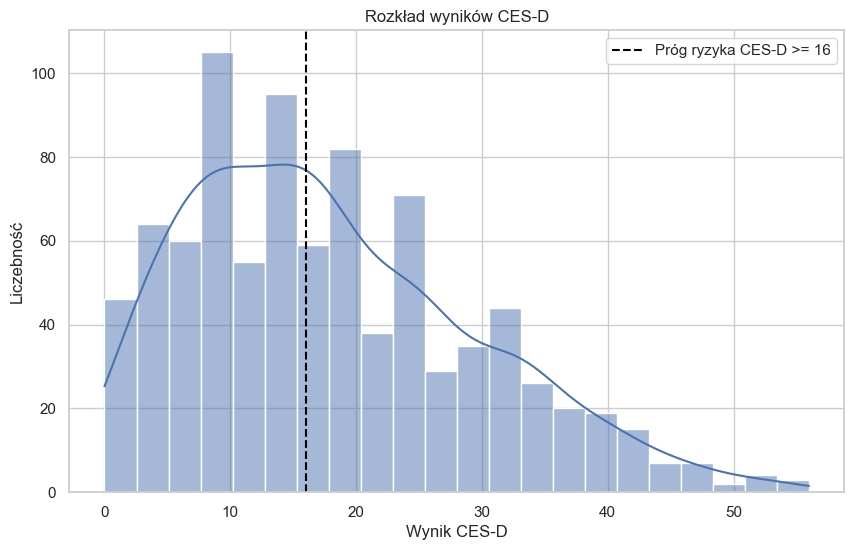

In [8]:
plt.figure()
sns.histplot(data=df, x="cesd", kde=True, bins=22)
plt.axvline(16, color="black", linestyle="--", label="Próg ryzyka CES-D >= 16")
plt.title("Rozkład wyników CES-D")
plt.xlabel("Wynik CES-D")
plt.ylabel("Liczebność")
plt.legend()
plt.show()

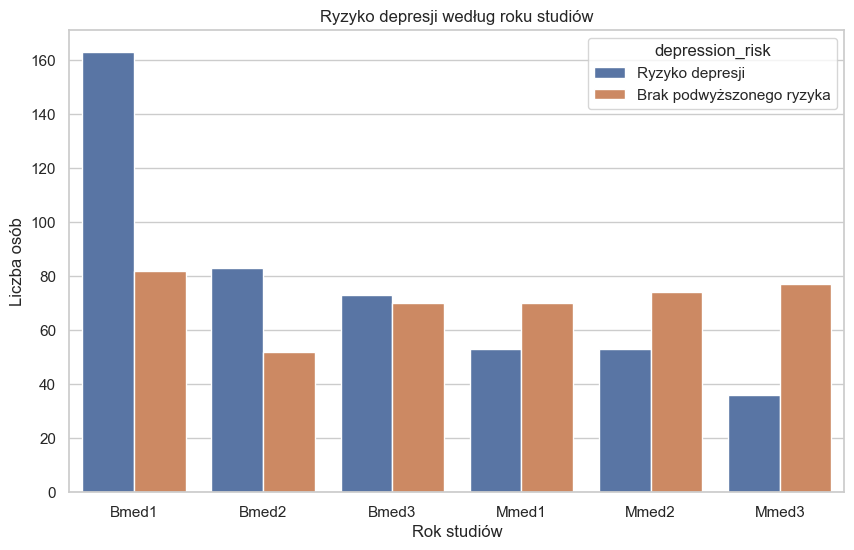

In [9]:
plt.figure()
sns.countplot(data=df, x="year_label", hue="depression_risk", order=["Bmed1", "Bmed2", "Bmed3", "Mmed1", "Mmed2", "Mmed3"])
plt.title("Ryzyko depresji według roku studiów")
plt.xlabel("Rok studiów")
plt.ylabel("Liczba osób")
plt.show()

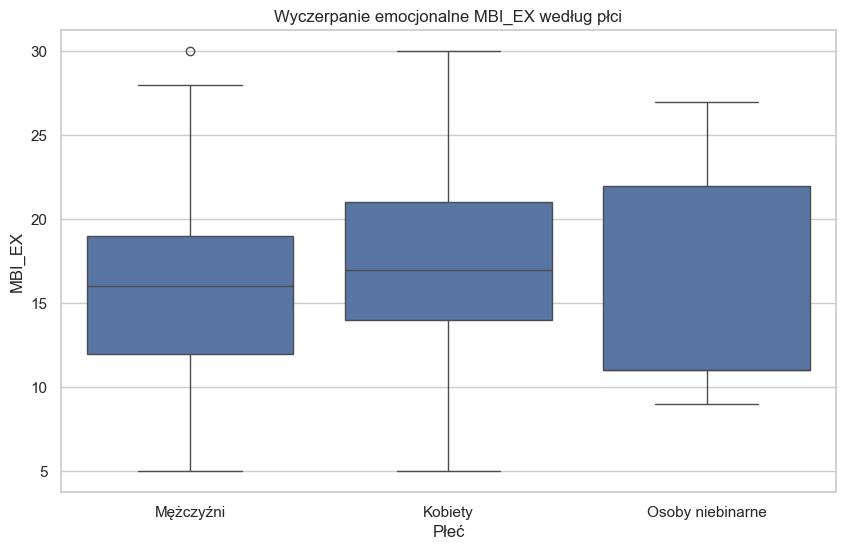

In [10]:
plt.figure()
sns.boxplot(data=df, x="sex_label", y="mbi_ex", order=["Mężczyźni", "Kobiety", "Osoby niebinarne"])
plt.title("Wyczerpanie emocjonalne MBI_EX według płci")
plt.xlabel("Płeć")
plt.ylabel("MBI_EX")
plt.show()

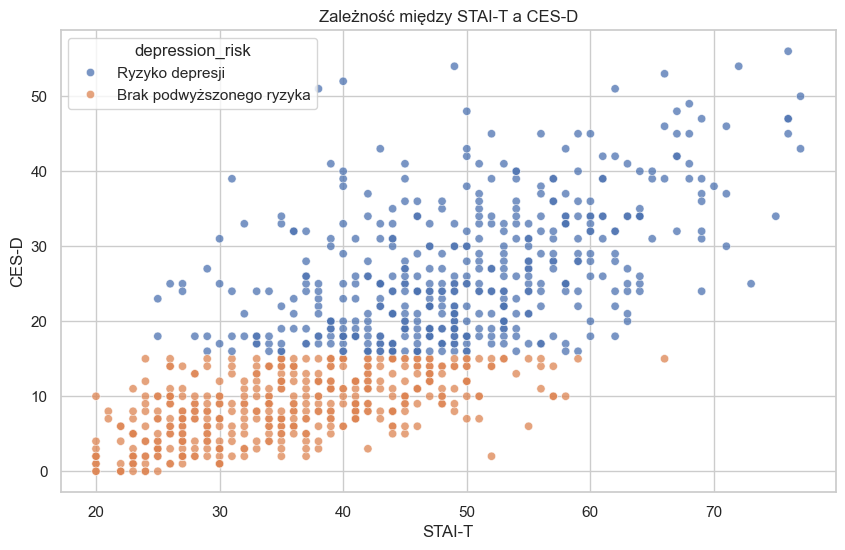

In [11]:
plt.figure()
sns.scatterplot(data=df, x="stai_t", y="cesd", hue="depression_risk", alpha=0.75)
plt.title("Zależność między STAI-T a CES-D")
plt.xlabel("STAI-T")
plt.ylabel("CES-D")
plt.show()

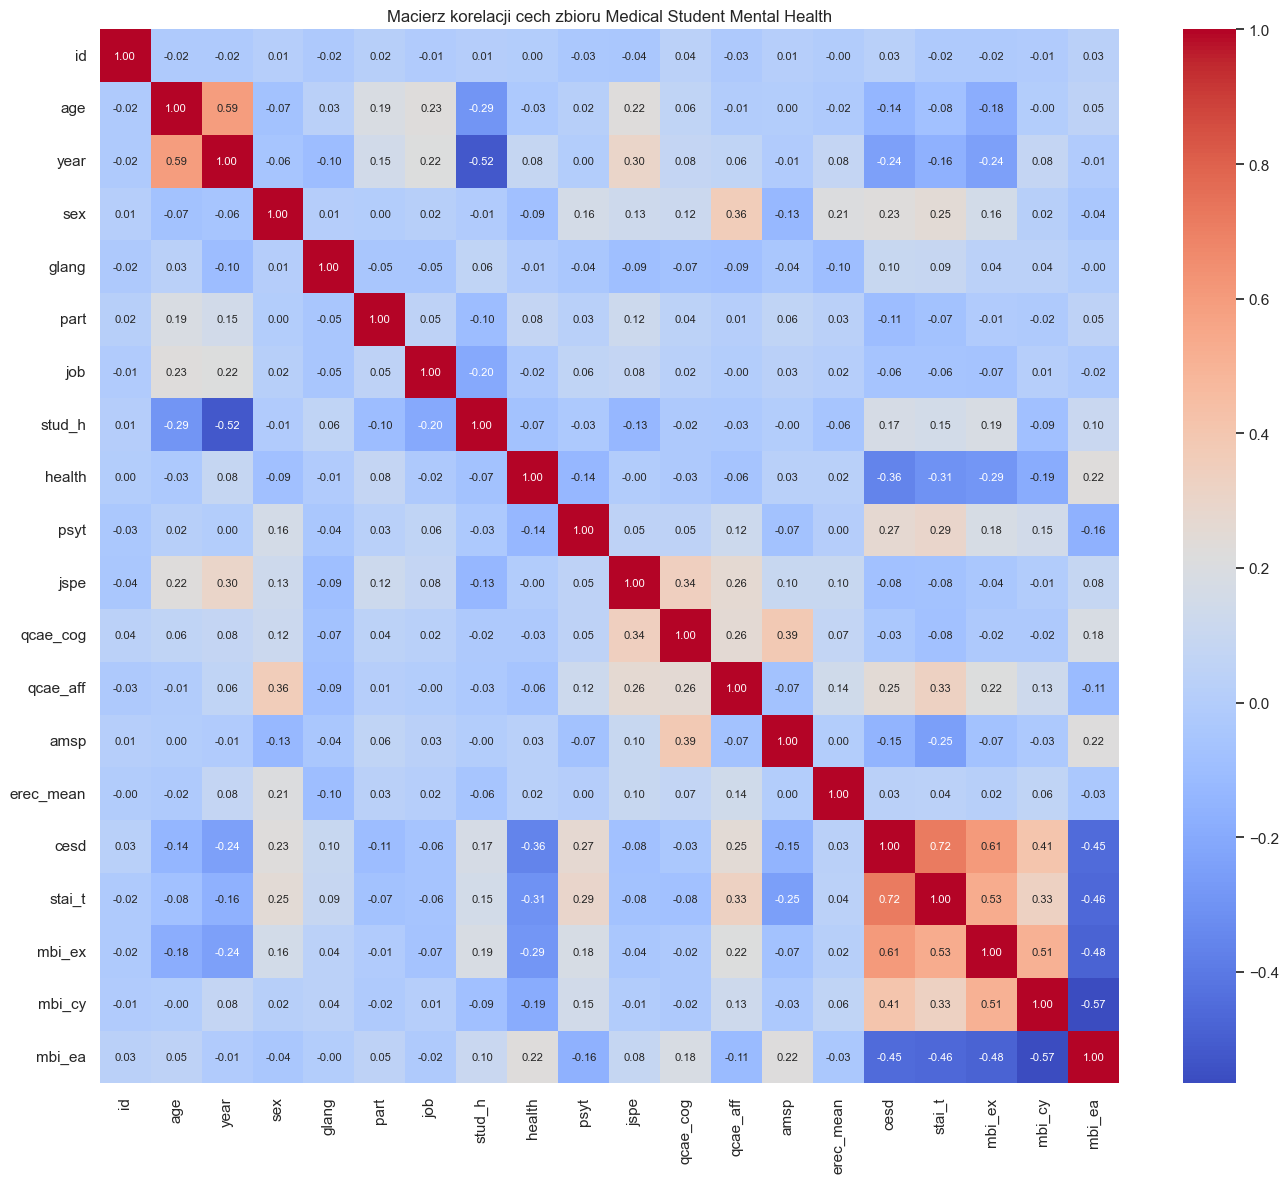

In [12]:
plt.figure(figsize=(14, 12))
numeric_df = df.drop(columns=["sex_label", "year_label", "depression_risk"]).apply(pd.to_numeric, errors="coerce")
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 8})
plt.title("Macierz korelacji cech zbioru Medical Student Mental Health")
plt.tight_layout()
plt.show()

# Hipoteza
Narastający cynizm akademicki jest najsilniejszym predyktorem kryzysu psychologicznego w modelu. Zakładamy, że wzrost poziomu cynizmu (mbi_cy), traktujemy jako mechanizm obronny studenta medycyny, bezpośrednio i najsilniej spośród wszystkich cech zwiększa prawdopodobieństwo znalezienia się w grupie ryzyka depresji CES-D >16.

# Aktualny stan wiedzy i inne rozwiązania dla podobnych problemów
W literaturze naukowej ryzyko depresji prognozuje się za pomocą kilku podejść. Klasyczne podejście opiera się na badaniach psychometrycznych ze standaryzowanymi kwestionariuszami (np. CES-D, STAI, MBI), których wyniki analizuje się statystycznie metodami korelacji i regresji.

Rosnącą popularnością cieszy się uczenie maszynowe. Modele klasyfikacyjne (np. regresja logistyczna, Random Forest, SVM, sieci neuronowe) przewidują objawy na podstawie danych demograficznych, psychologicznych i behawioralnych. Zaawansowane rozwiązania AI analizują duże zbiory danych z aplikacji czy platform edukacyjnych, a metody NLP (przetwarzanie języka naturalnego) pozwalają wykrywać sygnały pogorszenia stanu psychicznego bezpośrednio w wypowiedziach pacjentów.

Współcześnie najwyższą skuteczność wykazują się podejścia hybrydowe. Łączą one dane psychometryczne i behawioralne z uczeniem maszynowym, co pozwala tworzyć systemy wczesnego ostrzegania i skutecznie wdrażać profilaktykę.

## Propozycja modeli uczenia maszynowego (Machine Learning Candidates)

Na podstawie przeprowadzonej analizy eksploracyjnej danych, celem modeli będzie **przewidywanie poziomu depresji (zmienna `cesd`)** lub **lęku (`stai_t`)** u studentów medycyny na podstawie cech socjodemograficznych (wiek, płeć, rok studiów, obciążenie pracą) oraz innych wskaźników psychologicznych.

Poniżej przedstawiono charakterystykę, zalety oraz wady 4 wybranych algorytmów uczenia maszynowego rozważanych do tego zadania.

### 1. Regresja Logistyczna
* **Charakterystyka:** Klasyczny model statystyczny stosowany do zadań klasyfikacji. Zamiast przewidywać konkretną wartość liczbową, model szacuje prawdopodobieństwo przynależności do danej grupy (np. ryzyko depresji: tak/nie) na podstawie cech wejściowych (np. stud_h, age, sex). Wykorzystuje funkcję logistyczną (sigmoidę), która „ściąga” wyniki z równania liniowego do przedziału od 0 do 1.
* **Zalety:**
    * Dobra interpretowalność: Można sprawdzić, które cechy najmocniej wpływają na ryzyko depresji, bo model pokazuje znaczenie poszczególnych zmiennych.
    * Szybkość działania: Model jest prosty obliczeniowo, szybko się trenuje i dobrze sprawdza się przy mniejszych zbiorach danych.
    * Dobre dopasowanie do problemu klasyfikacji: Idealnie nadaje się do przewidywania binarnych scenariuszy, czyli czy student należy do grupy ryzyka, czy nie.
* **Wady:**
    * Zakłada liniowość w logarytmie szans: Regresja logistyczna zakłada, że wpływ cech na tzw. log-odds jest liniowy. Przez to może gorzej radzić sobie z wykrywaniem bardziej złożonych, nieliniowych relacji w danych bez wcześniejszej inżynierii cech.
    * Wrażliwość na dobór cech: Jakość modelu zależy od tego, jakie zmienne zostaną użyte, a silna współliniowość (gdy dwie cechy niosą niemal identyczną informację) może mocno zaburzyć interpretację wag.
* **Dopasowanie:**
    * Regresja logistyczna dobrze pasuje do analizowanej bazy danych, ponieważ zmienna CES-D może zostać przekształcona do postaci binarnej, np. brak ryzyka depresji oraz ryzyko depresji przy CES-D >= 16. W bazie znajduje się 886 obserwacji, a podział klas jest dość wyrównany: 455 osób bez ryzyka i 431 osób w grupie ryzyka, więc model ma sensowne warunki do uczenia, bez dużej dominacji jednej klasy.

### 2. Wielowarstwowy Perceptron (MLP – Multilayer Perceptron)
* **Charakterystyka:** Klasyczna, jednokierunkowa sztuczna sieć neuronowa. Składa się z warstwy wejściowej, warstw ukrytych z nieliniowymi funkcjami aktywacji (np. ReLU) oraz warstwy wyjściowej. Model ten uczy się zaawansowanych reprezentacji danych.
* **Zalety:**
    * **Potężna zdolność adaptacji:** Doskonale radzi sobie ze skomplikowanymi, nieliniowymi zależnościami oraz interakcjami wielu zmiennych jednocześnie.
    * **Uniwersalność:** Może służyć zarówno do prognozowania wartości ciągłych (regresja), jak i klasyfikacji studentów do grup ryzyka.
* **Wady:**
    * **Model typu „Czarna skrzynka” (Black Box):** Bardzo niska interpretowalność. Niemożliwe jest proste wyjaśnienie, które dokładnie cechy przeważyły ostateczną decyzję sieci.
    * **Wymaga dużych zbiorów danych:** Przy mniejszych bazach ankietowych (takich jak obecna) MLP ma silną tendencję do przeuczenia się (uczenia się danych treningowych na pamięć).
    * **Złożoność konfiguracji:** Wymaga czasochłonnego dostrajania architektury (liczba warstw, neuronów, współczynnik uczenia).
* **Dopasowanie:**
    * W tej bazie MLP może być szczególnie przydatny, ponieważ ryzyko depresji może zależeć nie od jednej cechy, ale od połączenia kilku zmiennych, np. poziomu lęku, wypalenia, cynizmu, empatii i stanu zdrowia. Model może więc lepiej uchwycić takie bardziej złożone relacje niż klasyczne modele liniowe.

### 3. Las Losowy (Random Forest)
* **Charakterystyka:** Algorytm zespołowy (ensemble) oparty na podejściu *Bagging*. Składa się z zestawu wielu niezależnych drzew decyzyjnych trenowanych równolegle. Końcowa prognoza jest średnią z wyników wszystkich pojedynczych drzew.
* **Zalety:**
    * **Odporność na wartości odstające:** Pojedyncze anomalie lub błędy w odpowiedziach studentów nie psują stabilności całego modelu.
    * **Brak konieczności skalowania danych:** Działa poprawnie niezależnie od rozkładu i jednostek zmiennych wejściowych.
    * **Wskaźnik ważności cech (Feature Importance):** Pozwala łatwo wygenerować ranking pokazujący, które pytania z kwestionariusza mają kluczowy wpływ na zdrowie psychiczne.
* **Wady:**
    * **Brak ciągłości w ekstrapolacji:** W zadaniach regresji model nie potrafi przewidzieć wartości wykraczających poza zakres danych treningowych (zwraca średnią z liścia).
    * **Duży rozmiar modelu:** Przy dużej liczbie głębokich drzew model może zużywać znaczne zasoby pamięci.
* **Dopasowanie:**
    * Random Forest wykorzystuje wiele drzew decyzyjnych do analizy danych z bazy Carrard et al. W modelu cechami wejściowymi są m.in. dane demograficzne i edukacyjne, takie jak age, sex, year, stud_h, a także zmienne psychologiczne, np. stai_t, mbi_ex, mbi_cy, mbi_ea, jspe, qcae_cog i qcae_aff.

### 4. Gradient Boosting (GBoost)
* **Charakterystyka:** Zaawansowany algorytm sekwencyjny. Kolejne drzewa decyzyjne budowane są jedno po drugim, gdzie każde następne drzewo jest celowo optymalizowane pod kątem redukcji błędów (reziduów) popełnionych przez swoich poprzedników.
* **Zalety:**
    * **Najwyższa skuteczność (State-of-the-art):** W przypadku danych tabelarycznych i kwestionariuszowych algorytmy te niemal zawsze osiągają najwyższą dokładność predykcji.
    * **Automatyczna obsługa braków danych:** Nowoczesne biblioteki (XGBoost/LightGBM) same uczą się, jak traktować puste komórki w bazie bez potrzeby wcześniejszej imputacji.
    * **Wbudowana regularyzacja:** Posiada zaawansowane mechanizmy chroniące model przed przeuczeniem.
* **Wady:**
    * **Wrażliwość na hiperparametry:** Model wymaga precyzyjnego nastrojenia (np. `learning_rate`, `max_depth`), aby nie dopasował się do szumu informacyjnego.
    * **Podatność na overfitting:** Przy zbyt głębokich drzewach i braku kontroli algorytm szybko straci zdolność generalizacji na nowe dane.
* **Dopasowanie:**
    * W tej bazie GBoost analizuje cechy studentów, takie jak wiek, płeć, rok studiów, liczba godzin nauki, stan zdrowia oraz wyniki skal psychologicznych. Na ich podstawie przewiduje, czy dana osoba znajduje się w grupie ryzyka depresji określonej przez wynik CES-D > 16.